In [3]:
!unzip "/content/archive (6).zip" -d "/content/extracted_folder"

Archive:  /content/archive (6).zip
  inflating: /content/extracted_folder/big_startup_secsees_dataset.csv  


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Direct file load karo
file_path = (
    '/content/extracted_folder/big_startup_secsees_dataset.csv'
)
df = pd.read_csv(file_path)

print(f'Total Rows & Columns: {df.shape}')
df.head()

Total Rows & Columns: (66368, 14)


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB

Missing Values (Top 15):
founded_at          15221
state_code           8547
region    

/tmp/ipykernel_6032/2835879625.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


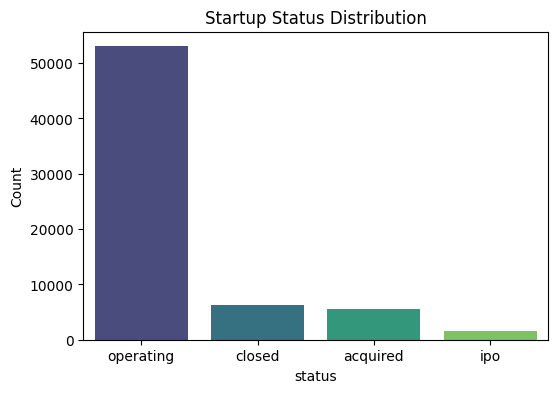

In [6]:
# Column types aur non-null count
df.info()

# Missing values check
missing = df.isnull().sum()
print('\nMissing Values (Top 15):')
print(missing[missing > 0].sort_values(ascending=False).head(15))

# Target count (acquired, closed, operating)
print('\nStatus Distribution:')
print(df['status'].value_counts(dropna=False))

# Target distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(
    x='status',
    data=df,
    order=df['status'].value_counts().index,
    palette='viridis',
)
plt.title('Startup Status Distribution')
plt.ylabel('Count')
plt.show()

In [7]:
# Operating startups ko alag holdout CSV me save kar lo
df_operating = df[df['status'] == 'operating'].copy()
df_operating.to_csv('operating_startups_unlabeled.csv', index=False)
print(f'Saved Operating Startups: {df_operating.shape}')

# Sirf acquired aur closed startups rakhein model training ke liye
df_clean = df[df['status'].isin(['acquired', 'closed'])].copy()

# Target binary create karein: Acquired = 1, Closed = 0
df_clean['target'] = df_clean['status'].map({'acquired': 1, 'closed': 0})
df_clean.drop(columns=['status'], inplace=True)

print(f'Train Data Shape: {df_clean.shape}')
print(df_clean['target'].value_counts())

Saved Operating Startups: (53034, 14)
Train Data Shape: (11787, 14)
target
0    6238
1    5549
Name: count, dtype: int64


In [8]:
# Unnecessary columns list
drop_cols = [
    'Unnamed: 0',
    'id',
    'name',
    'permalink',
    'homepage_url',
    'overview',
    'closed_at',  # closed_at data leakage cause karta hai
    'state_code.1',
    'id.1',  # duplicate join columns agar ho
]

# Drop columns jo actual dataframe me hain
df_clean = df_clean.drop(
    columns=[c for c in drop_cols if c in df_clean.columns]
)
print('Remaining Columns:', df_clean.shape[1])

Remaining Columns: 11


In [9]:
date_columns = [
    'founded_at',
    'first_funding_at',
    'last_funding_at',
    'first_milestone_at',
    'last_milestone_at',
]

for col in date_columns:
  if col in df_clean.columns:
    # Year extract karein
    df_clean[col + '_year'] = pd.to_datetime(
        df_clean[col], errors='coerce'
    ).dt.year
    # Median year fill karein missing values ke liye
    df_clean[col + '_year'] = df_clean[col + '_year'].fillna(
        df_clean[col + '_year'].median()
    )
    # Original text date drop karein
    df_clean.drop(columns=[col], inplace=True)

print('Dates successfully converted to years.')

Dates successfully converted to years.


In [10]:
date_columns = [
    'founded_at',
    'first_funding_at',
    'last_funding_at',
    'first_milestone_at',
    'last_milestone_at',
]

for col in date_columns:
  if col in df_clean.columns:
    # Year extract karein
    df_clean[col + '_year'] = pd.to_datetime(
        df_clean[col], errors='coerce'
    ).dt.year
    # Median year fill karein missing values ke liye
    df_clean[col + '_year'] = df_clean[col + '_year'].fillna(
        df_clean[col + '_year'].median()
    )
    # Original text date drop karein
    df_clean.drop(columns=[col], inplace=True)

print('Dates successfully converted to years.')

Dates successfully converted to years.


In [11]:
# Numeric aur Categorical columns alag karo
num_cols = (
    df_clean.select_dtypes(include=[np.number])
    .columns.drop('target')
    .tolist()
)
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# 1. Numeric Missing Values -> Median Imputation
for col in num_cols:
  df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 2. Categorical: Jo columns me 30 se zyada unique values hain unhe drop karo (e.g. specific cities/zips)
for col in cat_cols:
  if df_clean[col].nunique() > 30:
    df_clean.drop(columns=[col], inplace=True)
  else:
    # Missing category ko 'Unknown' se fill karo
    df_clean[col] = df_clean[col].fillna('Unknown')

# Re-evaluate categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# One-hot encoding
df_final = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print('Final Processed Data Shape:', df_final.shape)
print('Null values remaining in dataset:', df_final.isnull().sum().sum())

Final Processed Data Shape: (11787, 5)
Null values remaining in dataset: 0


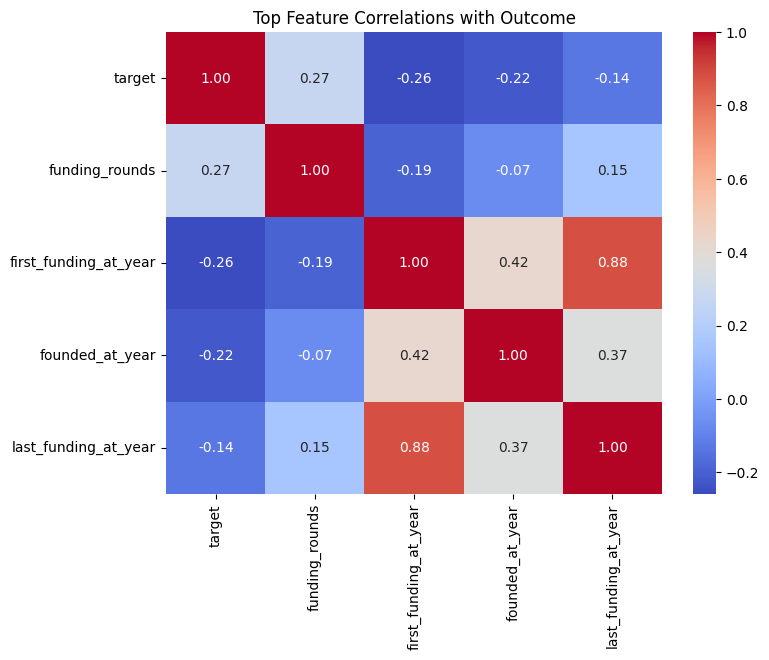

Dataset successfully cleaned and saved as cleaned_startup_data.csv!


In [12]:
# 1. Funding vs Success Boxplot (agar total_funding_usd column present ho)
if 'funding_total_usd' in df_final.columns:
  plt.figure(figsize=(7, 4))
  sns.boxplot(x='target', y='funding_total_usd', data=df_final, showfliers=False)
  plt.xticks([0, 1], ['Closed (0)', 'Acquired (1)'])
  plt.title('Total Funding vs Startup Outcome')
  plt.show()

# 2. Target ke saath Top 10 Correlated Features Heatmap
plt.figure(figsize=(8, 6))
top_corr = (
    df_final.corr()['target'].abs().sort_values(ascending=False).head(10).index
)
sns.heatmap(df_final[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top Feature Correlations with Outcome')
plt.show()

# 3. Cleaned dataset save karein ready for ML
df_final.to_csv('cleaned_startup_data.csv', index=False)
print('Dataset successfully cleaned and saved as cleaned_startup_data.csv!')